# Лабораторная работа 5

Сидимеков Дмитрий

In [1]:
!wget -O human_activity_recognition.zip https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip
!unzip -o human_activity_recognition.zip
!unzip -o 'UCI HAR Dataset.zip'
!ls -R

--2026-04-01 15:47:45--  https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘human_activity_recognition.zip’

human_activity_reco     [       <=>          ]  58.18M  43.6MB/s    in 1.3s    

2026-04-01 15:47:47 (43.6 MB/s) - ‘human_activity_recognition.zip’ saved [61005872]

Archive:  human_activity_recognition.zip
 extracting: UCI HAR Dataset.names   
 extracting: UCI HAR Dataset.zip     
Archive:  UCI HAR Dataset.zip
   creating: UCI HAR Dataset/
  inflating: UCI HAR Dataset/.DS_Store  
   creating: __MACOSX/
   creating: __MACOSX/UCI HAR Dataset/
  inflating: __MACOSX/UCI HAR Dataset/._.DS_Store  
  inflating: UCI HAR Dataset/activity_labels.txt  
  inflating: __MACOSX/UCI HAR Dataset/._activity_labels.txt

In [2]:
!ls './UCI HAR Dataset'
!cat './UCI HAR Dataset/activity_labels.txt'
!cat './UCI HAR Dataset/features_info.txt'
!cat './UCI HAR Dataset/features.txt'

activity_labels.txt  features_info.txt	features.txt  README.txt  test	train
1 WALKING
2 WALKING_UPSTAIRS
3 WALKING_DOWNSTAIRS
4 SITTING
5 STANDING
6 LAYING
Feature Selection 

The features selected for this database come from the accelerometer and gyroscope 3-axial raw signals tAcc-XYZ and tGyro-XYZ. These time domain signals (prefix 't' to denote time) were captured at a constant rate of 50 Hz. Then they were filtered using a median filter and a 3rd order low pass Butterworth filter with a corner frequency of 20 Hz to remove noise. Similarly, the acceleration signal was then separated into body and gravity acceleration signals (tBodyAcc-XYZ and tGravityAcc-XYZ) using another low pass Butterworth filter with a corner frequency of 0.3 Hz. 

Subsequently, the body linear acceleration and angular velocity were derived in time to obtain Jerk signals (tBodyAccJerk-XYZ and tBodyGyroJerk-XYZ). Also the magnitude of these three-dimensional signals were calculated using the Euclidean norm (tBod

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Чтение данных

In [4]:
from pathlib import Path
data_dir = Path('./UCI HAR Dataset')

features_df = pd.read_csv(
    data_dir / 'features.txt',
    sep='\\s+',
    header=None,
    names=['feature_id', 'feature_name']
)
raw_feature_names = features_df['feature_name'].tolist()

name_counts = {}
feature_names = []
for name in raw_feature_names:
    count = name_counts.get(name, 0)
    feature_names.append(name if count == 0 else f'{name}__{count}')
    name_counts[name] = count + 1

activity_labels = pd.read_csv(
    data_dir / 'activity_labels.txt',
    sep='\\s+',
    header=None,
    names=['activity_id', 'activity_name']
)
activity_map = dict(zip(activity_labels['activity_id'], activity_labels['activity_name']))

X_train = pd.read_csv(
    data_dir / 'train' / 'X_train.txt',
    sep='\\s+',
    header=None,
    names=feature_names
)
X_test = pd.read_csv(
    data_dir / 'test' / 'X_test.txt',
    sep='\\s+',
    header=None,
    names=feature_names
)

y_train = pd.read_csv(
    data_dir / 'train' / 'y_train.txt',
    sep='\\s+',
    header=None
).squeeze('columns')
y_test = pd.read_csv(
    data_dir / 'test' / 'y_test.txt',
    sep='\\s+',
    header=None
).squeeze('columns')

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'y_train: {y_train.shape} | y_test: {y_test.shape}')
print(f'Пропуски в X_train: {int(X_train.isna().sum().sum())}')

display(y_train.value_counts().sort_index().rename(index=activity_map).to_frame('count'))
display(X_train.head())

X_train: (7352, 561) | X_test: (2947, 561)
y_train: (7352,) | y_test: (2947,)
Пропуски в X_train: 0


,count
0,
WALKING,1226
WALKING_UPSTAIRS,1073
WALKING_DOWNSTAIRS,986
SITTING,1286
STANDING,1374
LAYING,1407


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [5]:
X_train.shape

(7352, 561)

## Decision Tree

Функции метрики и критерии однородности

In [6]:
def gini(y):
  classes, counts = np.unique(y, return_counts=True)
  p = counts / counts.sum()
  return (1.0 - (p**2).sum()).item()

def entropy(y: np.ndarray, eps: float = 1e-12) -> float:
    if y.size == 0:
        return 0.0
    classes, counts = np.unique(y, return_counts=True)
    p = counts.astype(float) / counts.sum()
    return (-p * np.log2(p + eps)).sum().item()


def mse_score(y_true, y_pred):
    y_true = (y_true).astype(np.float64)
    y_pred = (y_pred).astype(np.float64)
    diff = y_true - y_pred
    return float(np.mean(diff**2))

def mse_impurity(y):
    y = np.asarray(y, dtype=np.float64)
    if y.size == 0:
        return 0.0
    return float(np.mean((y - y.mean()) ** 2))


def _safe_div(num, den, zero_division=0.0):
    num = np.asarray(num, dtype=np.float64)
    den = np.asarray(den, dtype=np.float64)
    out = np.full_like(num, fill_value=float(zero_division), dtype=np.float64)
    mask = den != 0
    out[mask] = num[mask] / den[mask]
    if out.ndim == 0:
        return float(out.item())
    return out


def _classwise_stats(y_true, y_pred, labels=None):
    if labels is None:
        labels = np.unique(np.concatenate([y_true, y_pred]))
    labels = np.asarray(labels)

    tp = []
    fp = []
    fn = []
    support = []

    for label in labels:
        true_mask = y_true == label
        pred_mask = y_pred == label
        tp.append(np.sum(true_mask & pred_mask))
        fp.append(np.sum(~true_mask & pred_mask))
        fn.append(np.sum(true_mask & ~pred_mask))
        support.append(np.sum(true_mask))

    return (
        labels,
        np.asarray(tp, dtype=np.float64),
        np.asarray(fp, dtype=np.float64),
        np.asarray(fn, dtype=np.float64),
        np.asarray(support, dtype=np.float64),
    )


def accuracy_score(y_true, y_pred):
    return float((y_true == y_pred).mean())


def precision_score(y_true, y_pred, average="macro", pos_label=1, zero_division=0.0):
    labels, tp, fp, fn, support = _classwise_stats(y_true, y_pred)
    per_class = _safe_div(tp, tp + fp, zero_division=zero_division)

    if average == "micro":
        return float(_safe_div(tp.sum(), tp.sum() + fp.sum(), zero_division=zero_division))
    if average == "weighted":
        total = support.sum()
        if total == 0:
            return float(zero_division)
        return float(np.sum(per_class * support) / total)
    if average == "macro":
        return float(per_class.mean())
    raise ValueError("average must be one of: micro, macro, weighted")


def recall_score(y_true, y_pred, average="macro", pos_label=1, zero_division=0.0):
    labels, tp, fp, fn, support = _classwise_stats(y_true, y_pred)
    per_class = _safe_div(tp, tp + fn, zero_division=zero_division)

    if average == "micro":
        return float(_safe_div(tp.sum(), tp.sum() + fn.sum(), zero_division=zero_division))
    if average == "weighted":
        total = support.sum()
        if total == 0:
            return float(zero_division)
        return float(np.sum(per_class * support) / total)
    if average == "macro":
        return float(per_class.mean())
    raise ValueError("average must be one of: micro, macro, weighted")


def f1_score(y_true, y_pred, average="macro", pos_label=1, zero_division=0.0):
    labels, tp, fp, fn, support = _classwise_stats(y_true, y_pred)
    precision = _safe_div(tp, tp + fp, zero_division=zero_division)
    recall = _safe_div(tp, tp + fn, zero_division=zero_division)
    per_class = _safe_div(2 * precision * recall, precision + recall, zero_division=zero_division)

    if average == "micro":
        p_micro = _safe_div(tp.sum(), tp.sum() + fp.sum(), zero_division=zero_division)
        r_micro = _safe_div(tp.sum(), tp.sum() + fn.sum(), zero_division=zero_division)
        return float(_safe_div(2 * p_micro * r_micro, p_micro + r_micro, zero_division=zero_division))
    if average == "weighted":
        total = support.sum()
        if total == 0:
            return float(zero_division)
        return float(np.sum(per_class * support) / total)
    if average == "macro":
        return float(per_class.mean())
    raise ValueError("average must be one of: micro, macro, weighted")


In [7]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

In [8]:
class DecisionTree:
    def __init__(
        self,
        criterion: str | None = "gini",
        max_depth: int | None = None,
        classification: bool = True,
        min_samples_leaf: int = 1,
        min_samples_split: int = 2,
        k_features: int | None = None,
        max_thresholds=16,
        random_state=42,
    ):

        self.is_clf = classification
        if criterion is None:
            criterion = "gini" if classification else "mse"

        if classification:
            if criterion == "gini":
                self._criterion = gini
            elif criterion == "entropy":
                self._criterion = entropy
            else:
                raise ValueError(f"Unknown criterion: {criterion}")
        else:
            if criterion == "mse":
                self._criterion = mse_impurity
            else:
                raise ValueError(f"Unknown criterion: {criterion}")

        self.max_depth = max_depth
        self.min_samples_split = max(2, min_samples_split)
        self.min_samples_leaf = min_samples_leaf
        self.k_features = k_features
        self.max_thresholds = max_thresholds

        self.random_state = random_state
        self.rng = np.random.default_rng(random_state)

        self.root = None
        self.n_features_ = None
        self.n_classes_ = None

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        self.n_features_ = X.shape[1]

        if self.k_features is not None:
            self.n_features_ = min(self.k_features, self.n_features_)

        if self.is_clf:
            self.n_classes_ = int(np.unique(y).size)

        self.root = self._build_tree(X, y, depth=0)
        return self

    def _build_tree(self, X, y, depth):
        n_samples, n_features = X.shape
        if self._stop(y, depth, n_samples):
            leaf_value = self._leaf_value(y)
            return Node(value=leaf_value)

        feature_idx, threshold, gain = self._best_split(X, y)
        if feature_idx is None:
            leaf_value = self._leaf_value(y)
            return Node(value=leaf_value)

        mask_l = X[:, feature_idx] <= threshold
        mask_r = ~mask_l

        X_left, y_left = X[mask_l], y[mask_l]
        X_right, y_right = X[mask_r], y[mask_r]

        child_l = self._build_tree(X_left, y_left, depth + 1)
        child_r = self._build_tree(X_right, y_right, depth + 1)

        return Node(
            feature=feature_idx, threshold=threshold, left=child_l, right=child_r
        )

    def _stop(self, y, depth, n_samples):
        """
        Критерий останова построения дерева
        """
        if self.max_depth is not None and depth >= self.max_depth:
            return True
        if n_samples < self.min_samples_split:
            return True

        if self.is_clf:
            if np.unique(y).size == 1:
                return True
        else:
            if y.size > 0 and y.astype(np.float64).var() < 1e-8:
                return True
        return False

    def _leaf_value(self, y):
        """
        Значение листа (самое часто встречающееся среди y)
        """

        if self.is_clf:
            classes, counts = np.unique(y, return_counts=True)
            return classes[np.argmax(counts)].item()
        else:
            return y.astype(np.float64).mean().item()

    def _best_split(self, X, y):
        n_samples, n_features = X.shape
        pnt_impurity = self._criterion(y)
        best_gain = 0.0
        best_feature = None
        best_threshold = None

        if self.k_features is None or self.k_features >= n_features:
            features_indices = np.arange(n_features)
        else:
            features_indices = self.rng.permutation(n_features)[: self.k_features]

        for j in features_indices:
            X_col = X[:, j]

            uniq_vals = np.unique(X_col)
            if len(uniq_vals) <= 1:
                continue

            if len(uniq_vals) - 1 > self.max_thresholds:
                qs = np.linspace(0.0, 1.0, self.max_thresholds + 2)[1:-1]
                thresholds = np.unique(np.quantile(X_col, qs))
            else:
                thresholds = (uniq_vals[:-1] + uniq_vals[1:]) / 2

            for t in thresholds:
                mask_l = X_col <= t
                mask_r = ~mask_l

                n_l = int(mask_l.sum())
                n_r = int(mask_r.sum())

                if n_l < self.min_samples_leaf or n_r < self.min_samples_leaf:
                    continue

                y_l = y[mask_l]
                y_r = y[mask_r]

                H_l = self._criterion(y_l)
                H_r = self._criterion(y_r)

                weighted_H = (n_l / n_samples) * H_l + (n_r / n_samples) * H_r
                gain = pnt_impurity - weighted_H

                if gain > best_gain:
                    best_gain = gain
                    best_feature = j
                    best_threshold = t.item()

        return best_feature, best_threshold, best_gain

    def _predict_one(self, x):
        node = self.root
        while (node.left is not None) and (node.right is not None):
            if x[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.value

    def predict(self, X):
        X = np.asarray(X)
        preds = [self._predict_one(X[i]) for i in range(X.shape[0])]
        dtype = None if self.is_clf else np.float64

        if self.is_clf:
            return np.array(preds, dtype=dtype)
        else:
            return np.array(preds, dtype=dtype)

## Gradient Boosting

In [20]:
class GradientBoosting:
    def __init__(
        self,
        n_estimators: int = 100,
        lr=0.1,
        max_depth: int | None = None,
        min_samples_leaf: int = 1,
        min_samples_split: int = 2,
        k_features=None,
        max_thresholds=16,
        random_state=42,
    ):
        self.n_estimators = n_estimators
        self.lr = lr
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.min_samples_split = min_samples_split
        self.max_thresholds = max_thresholds
        self.random_state = random_state
        self.k_features = k_features

        self.history_ = {"train_metric": [], "val_metric": [], "iter": []}
        self.init_value_ = None
        self.classes_ = None
        self.trees_ = []
        self.rng = np.random.default_rng(random_state)

    def _softmax(self, logits):
        logits = logits - logits.max(axis=1, keepdims=True)
        exp_logits = np.exp(logits)
        return exp_logits / exp_logits.sum(axis=1, keepdims=True)

    def fit(self, X, y, X_val=None, y_val=None, metric_fn=None):
        X = np.asarray(X)
        y = np.asarray(y)
        if X_val is not None:
            X_val = np.asarray(X_val)
        if y_val is not None:
            y_val = np.asarray(y_val)

        n_samples = X.shape[0]
        self.trees_ = []
        self.history_ = {"train_metric": [], "val_metric": [], "iter": []}

        self.classes_ = np.sort(np.unique(y))
        n_classes = len(self.classes_)

        class_to_idx = {cls: i for i, cls in enumerate(self.classes_)}
        y_enc = np.array([class_to_idx[label] for label in y], dtype=np.int64)
        Y_ohe = np.eye(n_classes, dtype=np.float64)[y_enc]
        F = np.zeros((n_samples, n_classes), dtype=np.float64)

        for m in range(self.n_estimators):
            P = self._softmax(F)
            R = Y_ohe - P

            trees_m = []
            for k in range(n_classes):
                tree = DecisionTree(
                    criterion="mse",
                    classification=False,
                    max_depth=self.max_depth,
                    min_samples_leaf=self.min_samples_leaf,
                    min_samples_split=self.min_samples_split,
                    k_features=self.k_features,
                    max_thresholds=self.max_thresholds,
                    random_state=(self.random_state + m * n_classes + k),
                )
                tree.fit(X, R[:, k])
                pred_k = np.asarray(tree.predict(X), dtype=np.float64)
                F[:, k] += self.lr * pred_k
                trees_m.append(tree)

            self.trees_.append(trees_m)

            if metric_fn is not None:
                y_pred_train = self.predict(X)
                train_metric = metric_fn(y, y_pred_train)

                if X_val is not None and y_val is not None:
                    y_pred_val = self.predict(X_val)
                    val_metric = metric_fn(y_val, y_pred_val)
                else:
                    val_metric = None

                self.history_["iter"].append(m + 1)
                self.history_["train_metric"].append(train_metric)
                self.history_["val_metric"].append(val_metric)

            if metric_fn is not None and (m + 1) % 5 == 0:
                print(
                    f"Iteration {m + 1}/{self.n_estimators} | Train metric: {train_metric:.4f} | Val metric: {val_metric:.4f}"
                    if val_metric is not None
                    else f"Iteration {m + 1}/{self.n_estimators} | Train metric: {train_metric:.4f}"
                )

        return self

    def predict_proba(self, X):
        X = np.asarray(X)
        n_samples = X.shape[0]

        if self.classes_ is None:
            raise RuntimeError("no fit?")

        n_classes = len(self.classes_)
        F = np.zeros((n_samples, n_classes), dtype=np.float64)

        for trees_m in self.trees_:
            for k, tree in enumerate(trees_m):
                F[:, k] += self.lr * np.asarray(tree.predict(X), dtype=np.float64)

        return self._softmax(F)

    def predict(self, X):
        P = self.predict_proba(X)
        idx = np.argmax(P, axis=1)
        return self.classes_[idx]

## применение моделей

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [22]:
model_gb = GradientBoosting(
    n_estimators=20,
    lr=0.1,
    max_depth=3,
    min_samples_leaf=30,
    min_samples_split=40,
    k_features=None,
    max_thresholds=8,
    random_state=42,
)
model_gb.fit(X_train, y_train, X_val=X_val, y_val=y_val, metric_fn=accuracy_score)

Iteration 5/20 | Train metric: 0.9211 | Val metric: 0.9044
Iteration 10/20 | Train metric: 0.9325 | Val metric: 0.9235
Iteration 15/20 | Train metric: 0.9357 | Val metric: 0.9309
Iteration 20/20 | Train metric: 0.9413 | Val metric: 0.9341


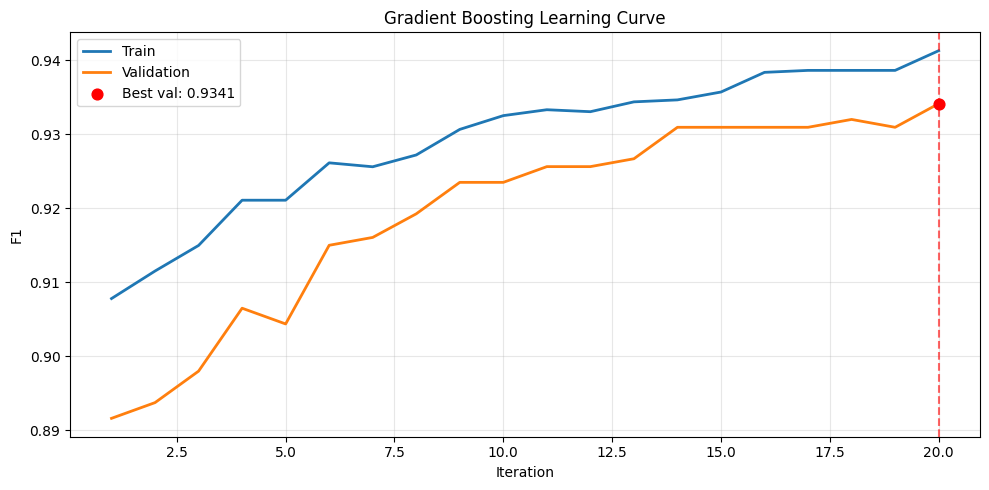

In [23]:
hist = model_gb.history_

iters = hist["iter"]
train_metric = hist["train_metric"]
val_metric = hist["val_metric"]

plt.figure(figsize=(10, 5))

plt.plot(iters, train_metric, label="Train", linewidth=2)
plt.plot(iters, val_metric, label="Validation", linewidth=2)

best_idx = int(np.argmax(val_metric))
best_iter = iters[best_idx]
best_val = val_metric[best_idx]

plt.scatter(
    best_iter, best_val, color="red", s=60, zorder=3, label=f"Best val: {best_val:.4f}"
)
plt.axvline(best_iter, color="red", linestyle="--", alpha=0.6)

plt.title("Gradient Boosting Learning Curve")
plt.xlabel("Iteration")
plt.ylabel("F1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

def roc_auc_graph(y_true, y_score, classes=None, title="ROC AUC"):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    if classes is None:
        classes = np.unique(y_true)
    classes = np.asarray(classes)

    y_true_bin = label_binarize(y_true, classes=classes)
    n_classes = len(classes)

    plt.figure(figsize=(8, 6))

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, linewidth=2, label=f"{cls} (AUC = {roc_auc:.3f})")

    macro_auc = roc_auc_score(y_true_bin, y_score, average="macro", multi_class="ovr")

    plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title} | macro AUC = {macro_auc:.3f}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

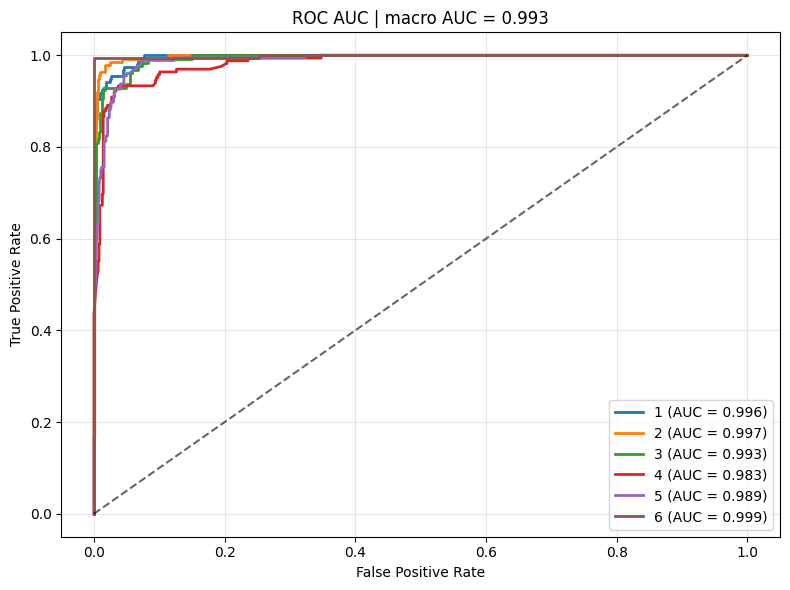

In [25]:
y_score = model_gb.predict_proba(X_val)
roc_auc_graph(y_val, y_score, classes=np.unique(y_train))

In [26]:
y_pred = model_gb.predict(X_val)

precision_macro = precision_score(y_val, y_pred)
recall_macro = recall_score(y_val, y_pred)
f1_macro = f1_score(y_val, y_pred)

print(f"Precision macro: {precision_macro:.4f}")
print(f"Recall macro: {recall_macro:.4f}")
print(f"F1 macro: {f1_macro:.4f}")

Precision macro: 0.9356
Recall macro: 0.9339
F1 macro: 0.9343
